# Part 1 — Structural Instability in Greek Sensitivity

**Goal**: Demonstrate that the sensitivity of SPX option Greeks to market moves is non-stationary across time.
A rolling OLS regression shows the relationship spikes during crisis periods and compresses during calm — motivating the formal 4-state HMM regime model in Part 2.

**Output**: Rolling coefficient plots + Chow test results for structural breaks.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from features import build_daily_features
from rolling_regression import rolling_ols, chow_test, rolling_coefficient_summary
from plots import plot_rolling_coefficients, KNOWN_CRISES

DATA = '../data'

In [2]:
# Load daily features (used as both Y candidates and X variables)
features = build_daily_features(
    f'{DATA}/cboeall1986.parquet',
    f'{DATA}/ff3.parquet',
    f'{DATA}/spx_clean.parquet',
)
print(f'Feature set: {len(features)} trading days')
features.head()

Feature set: 6022 trading days


,date,vix,vrp,momentum,opt_spread
0,1996-01-30,12.42,0.053911,0.0190,0.2500
1,1996-01-31,12.53,-0.132896,0.0214,0.3750
2,1996-02-01,12.65,0.397681,0.0265,0.2500
3,1996-02-02,13.23,0.926599,0.0318,0.2500
4,1996-02-05,13.46,0.972832,0.0408,0.3125


In [3]:
# Load SPX options — compute daily mean delta and gamma as Y variables
opts = pd.read_parquet(f'{DATA}/spx_clean.parquet')
opts['date'] = pd.to_datetime(opts['date'])
opts = opts[(opts['days_to_exp'].between(20, 45)) & (opts['put'] == 1)]

daily_greeks = opts.groupby('date')[['delta', 'gamma', 'vega', 'theta']].mean()
daily_greeks.columns = [f'avg_{c}' for c in daily_greeks.columns]

# Merge with features for X variables
panel = features.set_index('date').join(daily_greeks, how='inner')
panel = panel.sort_index()
print(f'Merged panel: {len(panel)} days')
panel.head()

Merged panel: 4123 days


,vix,vrp,momentum,opt_spread,avg_delta,avg_gamma,avg_vega,avg_theta
date,,,,,,,,
1996-01-31,12.53,-0.132896,0.0214,0.3750,-0.033237,0.001861,16.157140,-11.906750
1996-02-01,12.65,0.397681,0.0265,0.2500,-0.016504,0.000886,8.898182,-7.991354
1996-02-02,13.23,0.926599,0.0318,0.2500,-0.004762,0.000228,2.949301,-3.662386
1996-02-05,13.46,0.972832,0.0408,0.3125,-0.004592,0.000212,2.773273,-3.987398
1996-02-06,14.59,4.066182,0.0452,0.2500,-0.016689,0.000817,8.536281,-10.098290


Panel with mktrf: 4123 days


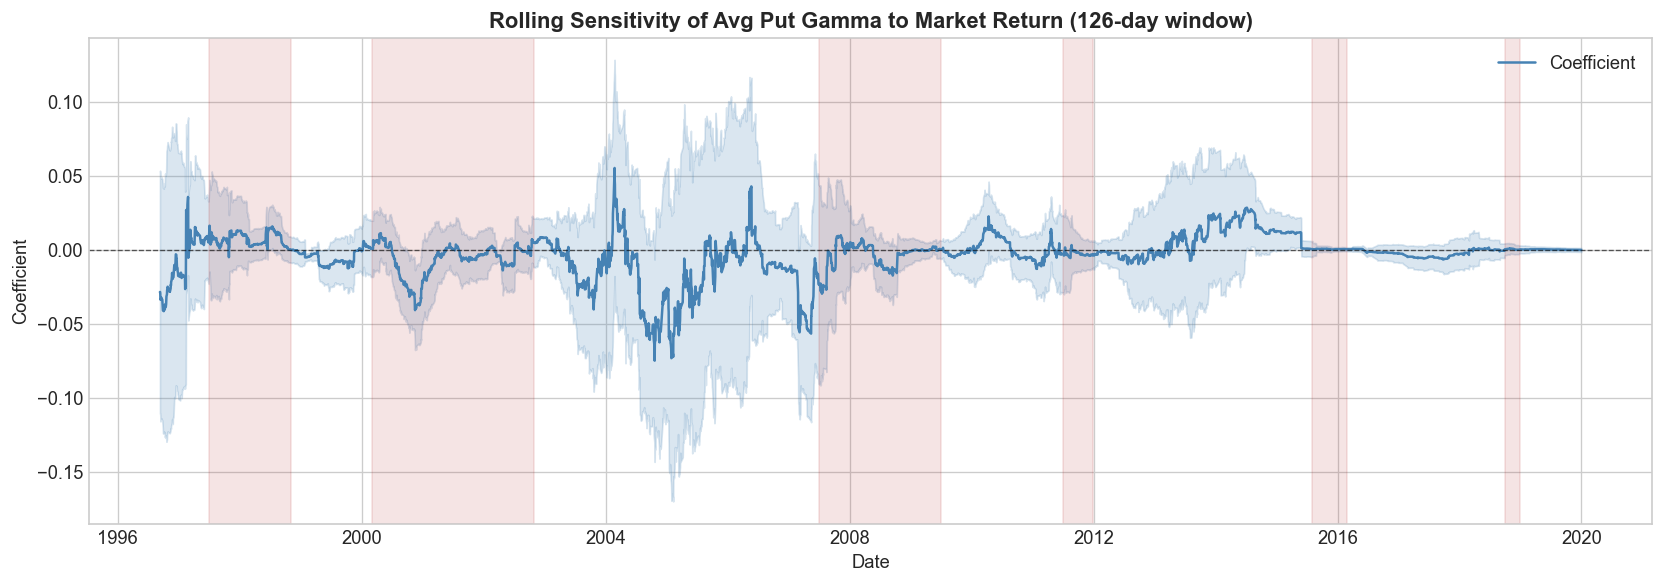

In [4]:
# --- Rolling regression: avg_gamma ~ VIX + mktrf (daily) ---
ff3 = pd.read_parquet(f'{DATA}/ff3.parquet')
ff3['date'] = pd.to_datetime(ff3['date'])
panel = panel.join(ff3.set_index('date')[['mktrf']], how='inner')
print(f'Panel with mktrf: {len(panel)} days')

rolling_gamma = rolling_ols(y=panel['avg_gamma'], X=panel[['vix', 'mktrf']], window=126)
fig = plot_rolling_coefficients(
    rolling_gamma,
    coef_col='mktrf_coef',
    se_col='mktrf_se',
    title='Rolling Sensitivity of Avg Put Gamma to Market Return (126-day window)',
)
plt.show()

**Reading the plot:** the 126-day rolling coefficient on `mktrf` swings between positive and negative values across the full sample rather than holding near a single constant — exactly what "non-stationary" means in practice. The widest, most volatile swings cluster around the shaded crisis windows, but as the next two cells show, that's not the whole story.

**Result:** F = 29.68, p ≈ 0.000 — the null of a single stable coefficient across the GFC break is rejected overwhelmingly. The relationship between avg put gamma and the market is not the same function before and after July 2007; treating it as one constant relationship (as a plain unconditional regression would) misses this entirely.

**Why this motivates Part 2:** the named crisis windows do show distinct average sensitivity levels, but notice that the "calm (all other)" bucket — the 2,586 days left over once the six known crises are carved out — has the *largest* standard deviation of any group (0.0173, wider than every individual crisis window). That bucket isn't actually homogeneous: it's a grab-bag of genuine calm, mild rising stress, and recovery, all lumped together because they don't fall inside a hand-picked historical crisis date range. A binary calm/crisis split — or any rule based on fixed historical windows — throws away exactly the structure we care about. That's the gap the 4-state HMM in Part 2 is built to close: instead of hand-picked windows, let the data itself define when a regime starts and ends.

In [5]:
# --- Chow test at GFC start (2007-07-01) ---
breakpoint_date = pd.Timestamp('2007-07-01')
breakpoint_idx = int(panel.index.searchsorted(breakpoint_date))
print(f'Breakpoint index: {breakpoint_idx} ({panel.index[breakpoint_idx].date()})')

chow_result = chow_test(y=panel['avg_gamma'], X=panel[['vix', 'mktrf']], breakpoint_idx=breakpoint_idx)
chow_result

Breakpoint index: 2385 (2007-07-05)


{'f_stat': np.float64(29.6814),
 'p_value': 0.0,
 'breakpoint_idx': 2385,
 'reject_h0': True}

In [6]:
# --- Rolling coefficient summary table ---
summary_mktrf = rolling_coefficient_summary(rolling_gamma, coef_col='mktrf_coef', crisis_periods=KNOWN_CRISES)
summary_vix = rolling_coefficient_summary(rolling_gamma, coef_col='vix_coef', crisis_periods=KNOWN_CRISES)

print('Market-return sensitivity (mktrf_coef) by period:')
display(summary_mktrf)
print()
print('VIX sensitivity (vix_coef) by period:')
display(summary_vix)

Market-return sensitivity (mktrf_coef) by period:


,period,mean,std,min,max,n_days
0,Asian+LTCM,0.0071,0.0043,-0.0050,0.0163,279
1,Dot-com,-0.0067,0.0109,-0.0408,0.0113,555
2,GFC,-0.0036,0.0081,-0.0297,0.0099,398
3,Euro debt,-0.0024,0.0015,-0.0056,0.0032,101
4,China shock,0.0004,0.0002,0.0002,0.0007,61
5,Q4 2018,0.0004,0.0003,0.0000,0.0009,18
6,calm (all other),-0.0058,0.0173,-0.0750,0.0553,2586



VIX sensitivity (vix_coef) by period:


,period,mean,std,min,max,n_days
0,Asian+LTCM,-0.0001,0.0001,-0.0003,0.0001,279
1,Dot-com,-0.0000,0.0001,-0.0002,0.0001,555
2,GFC,-0.0000,0.0001,-0.0001,0.0001,398
3,Euro debt,-0.0000,0.0000,-0.0000,0.0000,101
4,China shock,-0.0000,0.0000,-0.0000,0.0000,61
5,Q4 2018,-0.0000,0.0000,-0.0000,-0.0000,18
6,calm (all other),-0.0000,0.0001,-0.0004,0.0004,2586
